# Rice Grain Classification Using Logistic Regression
## 1. Data Exploration

In [4]:
# Install this to load the dataset .arff file
!pip install liac-arff

In [5]:
import arff
import pandas as pd

with open('/content/sample_data/Rice_Cammeo_Osmancik.arff', 'r') as f:
    dataset = arff.load(f)

# Extract attributes for column names and data for rows
columns = [attr[0] for attr in dataset['attributes']]
df = pd.DataFrame(dataset['data'], columns=columns)
df.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,Cammeo
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,Cammeo
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,Cammeo
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,Cammeo
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,Cammeo


Now we can explore the dataset's attributes.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3810 non-null   int64  
 1   Perimeter          3810 non-null   float64
 2   Major_Axis_Length  3810 non-null   float64
 3   Minor_Axis_Length  3810 non-null   float64
 4   Eccentricity       3810 non-null   float64
 5   Convex_Area        3810 non-null   int64  
 6   Extent             3810 non-null   float64
 7   Class              3810 non-null   object 
dtypes: float64(5), int64(2), object(1)
memory usage: 238.3+ KB


In [7]:
df.describe()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
count,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000
mean,12667.727559,454.239180,188.776222,86.313750,0.886871,12952.496850,0.661934
std,1732.367706,35.597081,17.448679,5.729817,0.020818,1776.972042,0.077239
min,7551.000000,359.100006,145.264465,59.532406,0.777233,7723.000000,0.497413
25%,11370.500000,426.144753,174.353855,82.731695,0.872402,11626.250000,0.598862
50%,12421.500000,448.852493,185.810059,86.434647,0.889050,12706.500000,0.645361
75%,13950.000000,483.683746,203.550438,90.143677,0.902588,14284.000000,0.726562
max,18913.000000,548.445984,239.010498,107.542450,0.948007,19099.000000,0.861050


In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

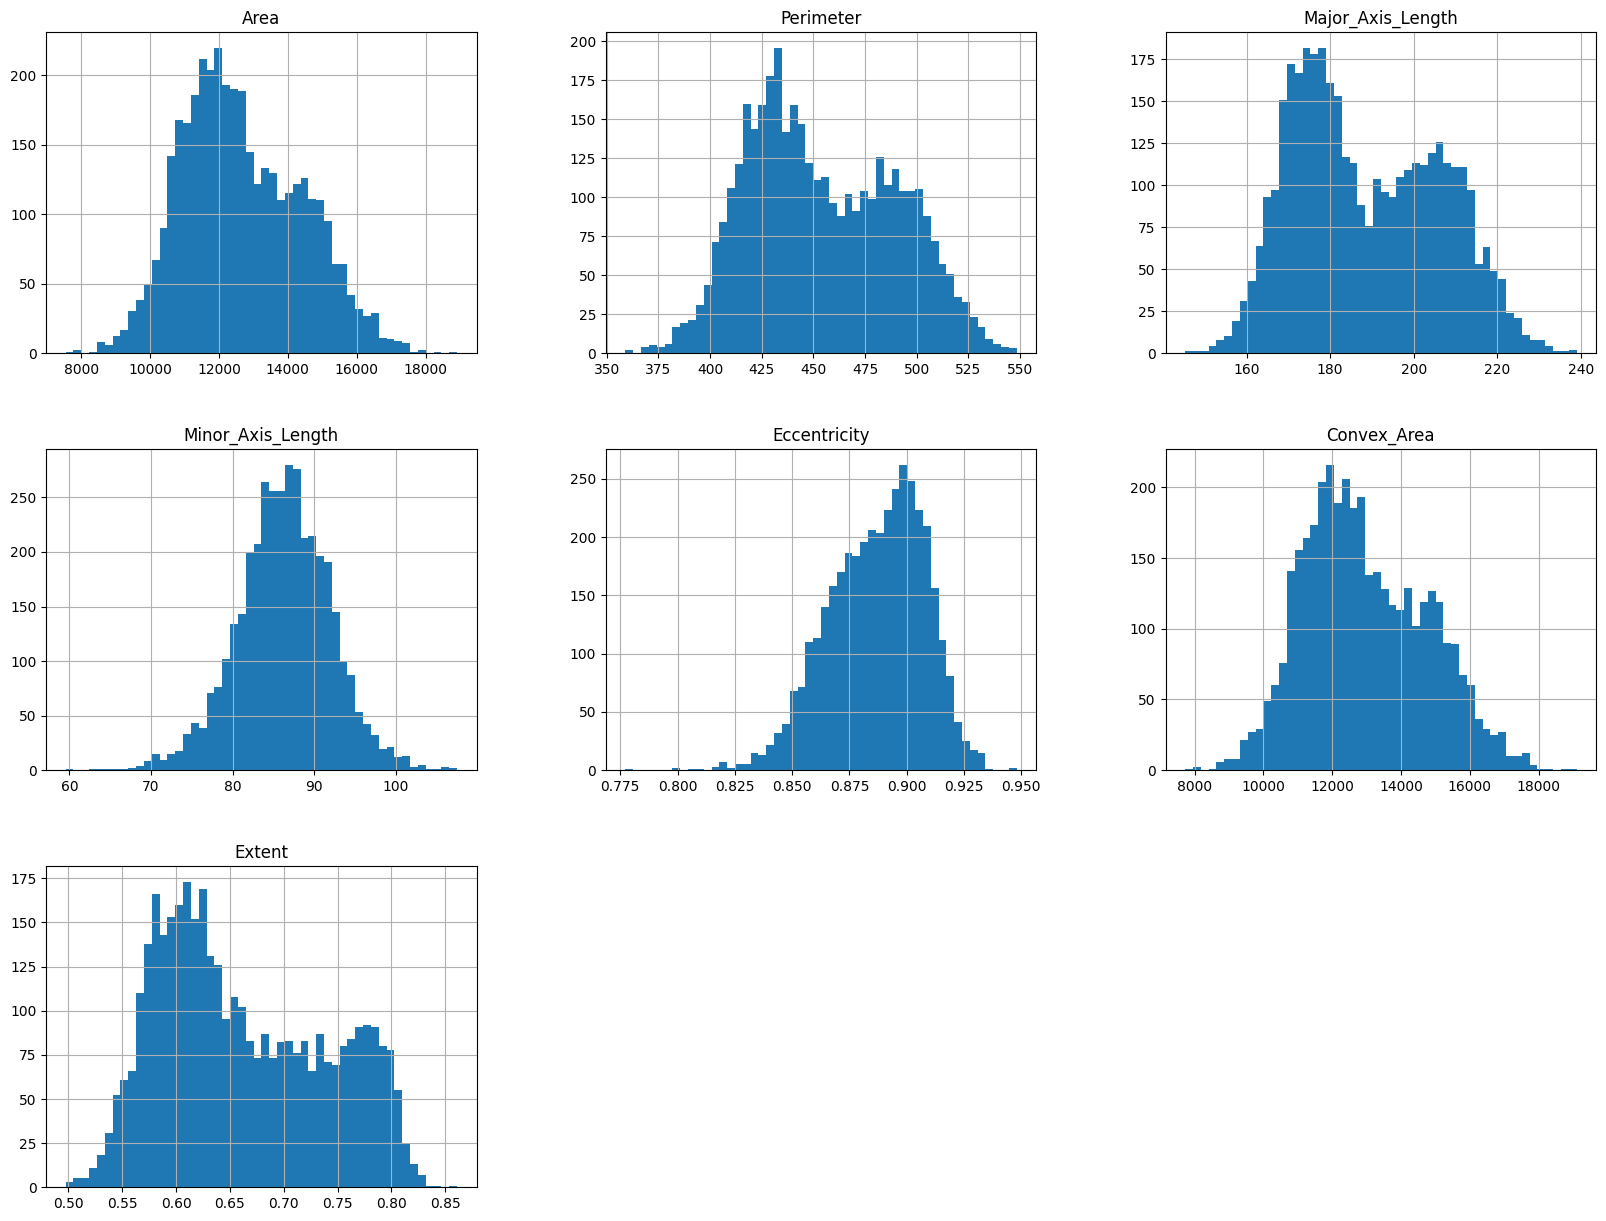

In [9]:
df.hist(bins=50, figsize=(20,15))
plt.show()

In [10]:
# Displays total counts for each unique label in the Class column
df['Class'].value_counts()

,count
Class,
Osmancik,2180
Cammeo,1630


/tmp/ipykernel_1083/2845177710.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', palette='Set2')


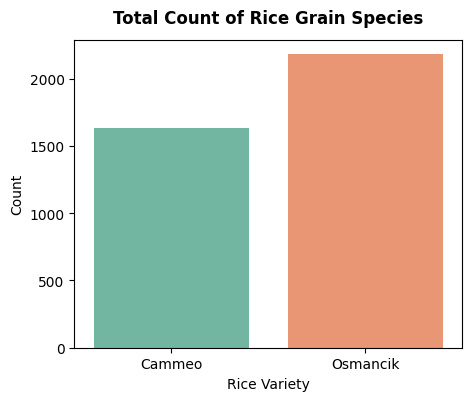

In [11]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Class', palette='Set2')

plt.title('Total Count of Rice Grain Species', fontsize=12, pad=12, fontweight='bold')
plt.xlabel('Rice Variety')
plt.ylabel('Count')

plt.show()

## 2. Pre-Processing

In [12]:
X = df.drop(columns=['Class'])
y = df['Class']
# Convert text classes ('Cammeo', 'Osmancik') into 1s and 0s
y = y.map({'Osmancik': 0, 'Cammeo': 1})

## 3. Splitting the dataset into Training and Testing Sets

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=42,    # Ensures you get the exact same split every time you run it
    stratify=y          # Maintains class balance in both splits
)

## 4. Scaling the features

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler ONLY on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the SAME scaler (do not re-fit!)
X_test_scaled = scaler.transform(X_test)

In [15]:
# Check if our feature scaling worked correctly
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")
print(f"Class distribution in training set:\n{y_train.value_counts(normalize=True)}")

Training features shape: (3048, 7)
Testing features shape: (762, 7)
Class distribution in training set:
Class
0    0.572178
1    0.427822
Name: proportion, dtype: float64


## 5. Logistic Regression - Model Training

In [16]:
from sklearn.linear_model import LogisticRegression

# L1 regularization as penality againist model complexity to prevent overfitting
# "solver = liblinear" as small dataset
lr = LogisticRegression(l1_ratio=1.0, C=1.0, solver='liblinear', max_iter=1000)

# Train the LR model using training set
lr.fit(X_train_scaled, y_train)

# Run the predictions on the testing set
y_pred_test = lr.predict(X_test_scaled)

# Print the initial training and test accuracy
print('Training accuracy: ', lr.score(X_train_scaled, y_train))
print('Test accuracy: ', lr.score(X_test_scaled, y_test))

Training accuracy:  0.931758530183727
Test accuracy:  0.9212598425196851


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


## 6. Model Evaluation

### 6.1. Prediction Performance Summary

In [17]:
# Side-by-side comparison of actual values vs. predicted values from the LR model
pred_test_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_test, 'Correct?': y_test == y_pred_test})

# Brief prediction summary
print(f"Total samples: {len(pred_test_df)}")
print(f"Correct predictions: {sum(pred_test_df['Correct?'])}")
print(f"Incorrect predictions: {len(pred_test_df) - sum(pred_test_df['Correct?'])}")

# Only shows the misclassified samples
misclass_samples = pred_test_df[pred_test_df['Correct?'] == False]
print(f"\nMisclassified samples: ")
print(misclass_samples)

Total samples: 762
Correct predictions: 702
Incorrect predictions: 60

Misclassified samples: 
      Actual  Predicted  Correct?
2725       0          1     False
518        1          0     False
1190       1          0     False
2238       0          1     False
1683       0          1     False
1141       1          0     False
396        1          0     False
320        1          0     False
514        1          0     False
82         1          0     False
632        1          0     False
1086       1          0     False
3490       0          1     False
2734       0          1     False
1179       1          0     False
1580       1          0     False
3804       0          1     False
2543       0          1     False
2445       0          1     False
2427       0          1     False
3417       0          1     False
1581       1          0     False
3663       0          1     False
492        1          0     False
993        1          0     False
3266       0         

### 6.2. Precision, Recall, F1 Score, and Confusion Matrix

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Precision, Recall, F1
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

print(f'\nPrecision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 score: {f1:.4f}')

# Confusion matrix to better understand precision/recall scores
print('\nConfusion matrix:')
print(confusion_matrix(y_test, y_pred_test))

# Classification report for more details into precision, recall, and f1
print('\nFinal classification report:')
print(classification_report(y_test, y_pred_test))


Precision: 0.9030
Recall: 0.9141
F1 score: 0.9085

Confusion matrix:
[[404  32]
 [ 28 298]]

Final classification report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       436
           1       0.90      0.91      0.91       326

    accuracy                           0.92       762
   macro avg       0.92      0.92      0.92       762
weighted avg       0.92      0.92      0.92       762



### Classification Results Explanation

The model achieved an overall accuracy of 92%. The precision, recall, and F1-score are all around 0.91–0.92, which indicates that the model performs consistently when classifying the two rice grain species.

The confusion matrix shows that most samples were classified correctly. Only a small number of Osmancik and Cammeo samples were misclassified.



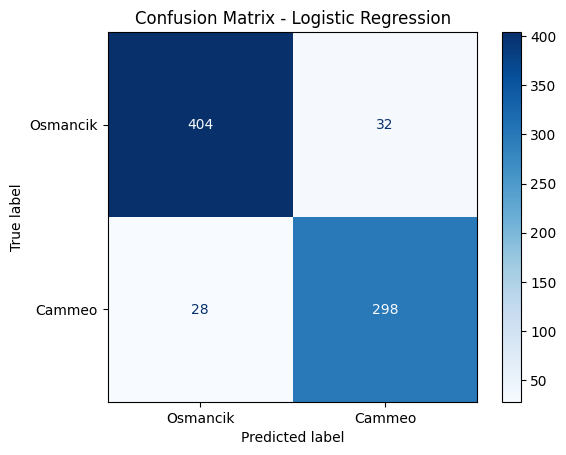

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Osmancik', 'Cammeo']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

### Confusion Matrix Explanation

The confusion matrix shows that most rice samples were classified correctly.  
404 Osmancik and 298 Cammeo samples were correctly predicted, while only 32 Osmancik and 28 Cammeo samples were misclassified.


### 6.2. ROC Curve

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


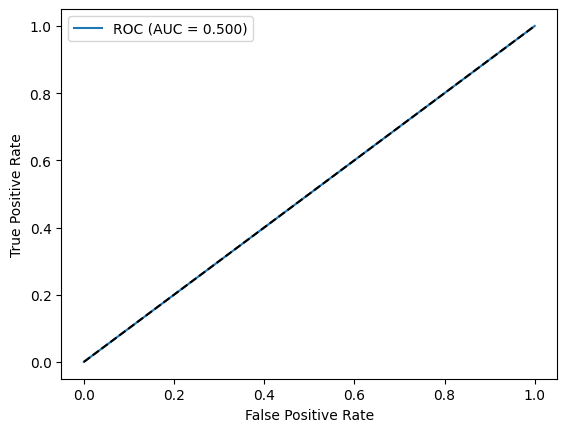

In [19]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities and compute ROC curve metrics
y_pred_proba = lr.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve with AUC score and diagonal reference line
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')

# Add axis labels, legend, and display the plot
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# User Manual

### 1. Development Environment

This project can be run using Google Colab or Jupyter Notebook. Python 3 is required to execute the notebook and train the Logistic Regression model. Google Colab is recommended because it provides an online Python environment and does not require a local Python installation.

The project uses the following Python libraries:

- liac-arff
- pandas
- matplotlib
- seaborn
- scikit-learn

If the required libraries are not installed, they can be installed using:

`pip install liac-arff pandas matplotlib seaborn scikit-learn`


### 2. Required Files

The following files are required:

- `rice-grain-classification.ipynb`
- `Rice_Cammeo_Osmancik.arff`

The notebook file contains the Python source code, while the ARFF file contains the rice grain dataset used for training and testing.

The dataset file name must match the file name used in the notebook code:

`Rice_Cammeo_Osmancik.arff`


### 3. Running the Project

1. Open Google Colab or Jupyter Notebook.
2. Open `rice-grain-classification.ipynb`.
3. If Google Colab is used, upload `Rice_Cammeo_Osmancik.arff` to the Colab working directory.
4. Run the package installation cell if required.
5. Run all notebook cells from top to bottom in order.
6. Do not skip the data preprocessing, train-test split, or feature scaling cells.
7. Wait for each cell to finish before continuing to the next cell.

In Google Colab, the user can also select:

`Runtime → Run all`

after the dataset has been uploaded.


### 4. Model Training and Testing

The notebook first loads and explores the rice grain dataset.

The class labels are converted into numerical values:

- Osmancik = 0
- Cammeo = 1

The dataset is then divided into training and testing sets. 80% of the data is used for training and 20% is used for testing.

The numerical features are standardised using `StandardScaler`.

A Logistic Regression model is then trained using the training dataset and tested using the testing dataset.


### 5. Expected Results

After the notebook is executed successfully, the user should be able to see:

- Dataset information
- Data distribution graphs
- Training and testing accuracy
- Precision
- Recall
- F1-score
- Classification Report
- Confusion Matrix
- Confusion Matrix visualisation
- ROC Curve

The current model achieves approximately:

- Training Accuracy: 93.21%
- Testing Accuracy: 92.13%

These results show the performance of the Logistic Regression model in classifying Cammeo and Osmancik rice grains.


### 6. Troubleshooting

If a `FileNotFoundError` occurs, check that `Rice_Cammeo_Osmancik.arff` has been uploaded and that the file name matches the notebook code exactly.

If the `arff` library cannot be imported, install it using:

`pip install liac-arff`

If variables such as `X_train`, `y_test`, or `lr` are not defined, some earlier cells may have been skipped. Run the notebook again from the top.

If Google Colab is restarted or disconnected, the ARFF dataset may need to be uploaded again.
